Low level sensitivity analysis:
- Performs analysis of data generated by [LL_sensitivity.py](LL_sensitivity.py), varying low level parameters (temperature, pressure, nozzle gas flow rate, nozzle diameter)

In [24]:
""" what range of gas flow rates fit the Kanai correlation  for d_b? (3-10 cm3/s)"""
from sparging.config import ureg
import sparging.correlations as corr
import numpy as np

ndots = np.linspace(40,400,5) * ureg.sccm
temps = np.array([450, 600, 700]) * ureg.K
vdots = corr.flow_g_vol.function(ndots, temps[2], 1*ureg.atm).to("cm**3/s")
print([(ndot, vdot) for ndot, vdot in zip(ndots, vdots)])

[(<Quantity(40.0, 'sccm')>, <Quantity(1.70941905, 'centimeter ** 3 / second')>), (<Quantity(130.0, 'sccm')>, <Quantity(5.55561191, 'centimeter ** 3 / second')>), (<Quantity(220.0, 'sccm')>, <Quantity(9.40180478, 'centimeter ** 3 / second')>), (<Quantity(310.0, 'sccm')>, <Quantity(13.2479976, 'centimeter ** 3 / second')>), (<Quantity(400.0, 'sccm')>, <Quantity(17.0941905, 'centimeter ** 3 / second')>)]


In [25]:
import pandas as pd
from pathlib import Path
from sparging.config import ureg
import json

CLEAN = True
EMULATOR = False
FOLDER = Path("datasets/20260510_233508")

X = pd.read_csv(FOLDER / "simulator_inputs.csv")
Y = pd.read_csv(FOLDER / "simulator_outputs.csv")

problem = json.load(open(FOLDER / "problem.json"))

units_dict ={
    "temperature": "Celsius",
    "P_top": "bar",
    "flow_g_mol": "sccm",
    "nozzle_diameter": "m"
}

names_dict ={
    "temperature": "Salt temperature",
    "P_top": "Vessel pressure",
    "flow_g_mol": "Sparging gas flow rate",
    "nozzle_diameter": "Nozzle diameter",
    "tau": "Extraction time",
    "d_b": "Bubbles diameter",
    "eps_g": "Gas fraction",
    "u_g0": "Bubbles velocity"
}

if EMULATOR:
    from autoemulate import AutoEmulate
    model = AutoEmulate.load_model("datasets/20260427_103531/RadialBasisFunctions_2.joblib")

In [26]:
from autoemulate.core.sensitivity_analysis import SensitivityAnalysis
if EMULATOR:
    # === Sensitivity analysis ===
    sa = SensitivityAnalysis(model, problem=problem)
    sobol_df = sa.run("sobol")
    sa.plot_sobol(sobol_df, index="ST", fname="out.svg")

    # get patches
    import matplotlib.pyplot as plt

    for i, patch in enumerate(plt.gca().get_children()):
        print(f"Patch {i}: {patch}")
        if i ==0:
            patch.set_color("red")
        elif i < 4:
            patch.set_alpha(0.5)

    plt.savefig("out2.svg")

In [27]:
if EMULATOR:
    from autoemulate.core.sensitivity_analysis import SensitivityAnalysis

    # print(problem)

    sa = SensitivityAnalysis(model, problem=problem)
    sobol_df = sa.run("sobol")
    list = []
    for i,string in enumerate(sobol_df["parameter"]):
        list.append(str(string).replace("np.str_","").replace("'", "").replace('(', "").replace(')', "").replace(', ', "_"))

    sa.plot_sobol(sobol_df, index="S1", figsize=(10, 8), fname=FOLDER / "postprocessing/sobol1.png")
    sa.plot_sobol(sobol_df, index="S2", figsize=(10, 8), fname=FOLDER / "postprocessing/sobol2.png") 
    sa.plot_sobol(sobol_df, index="ST", figsize=(10, 8), fname=FOLDER / "postprocessing/sobolTot.png")

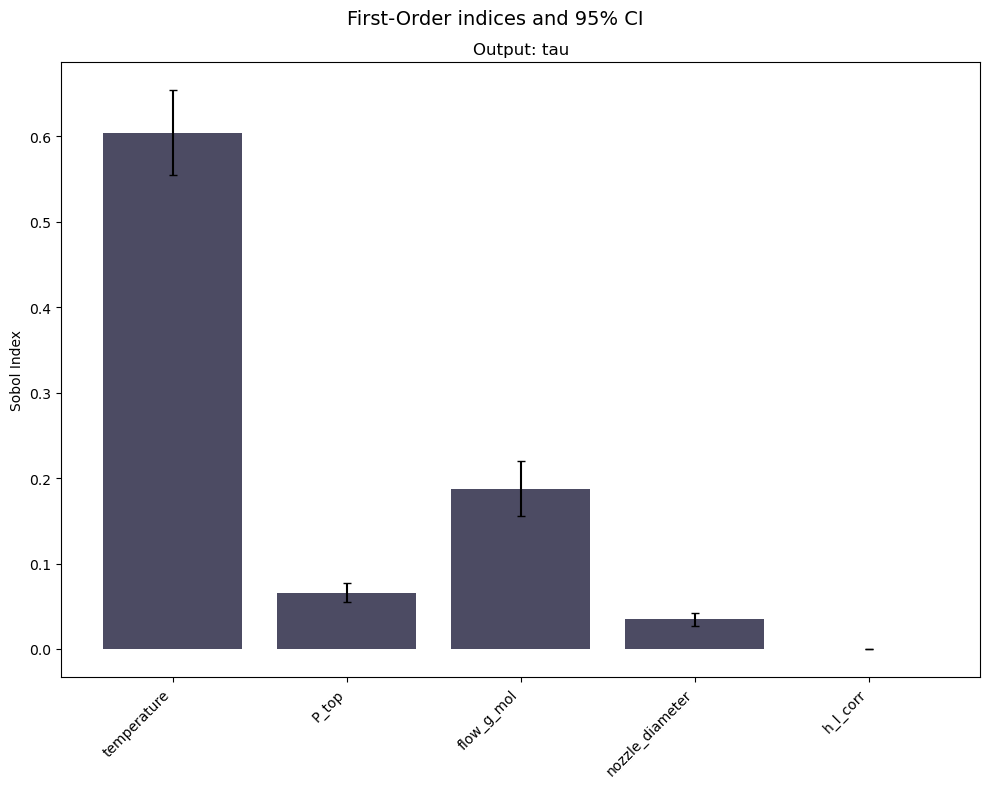

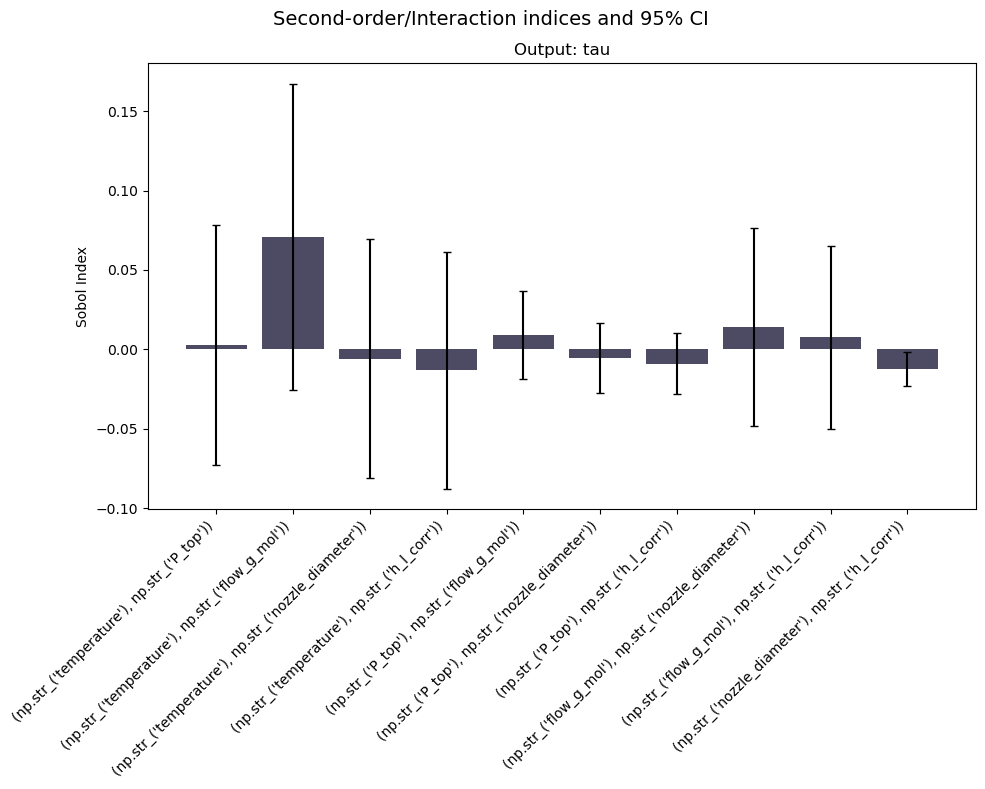

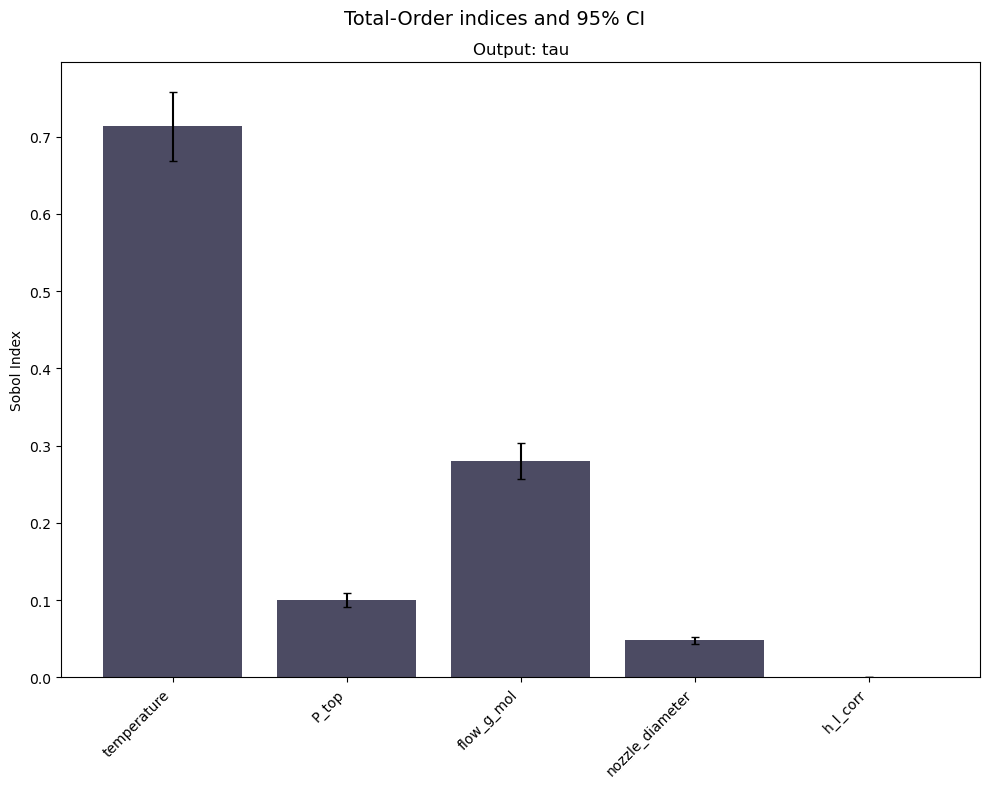

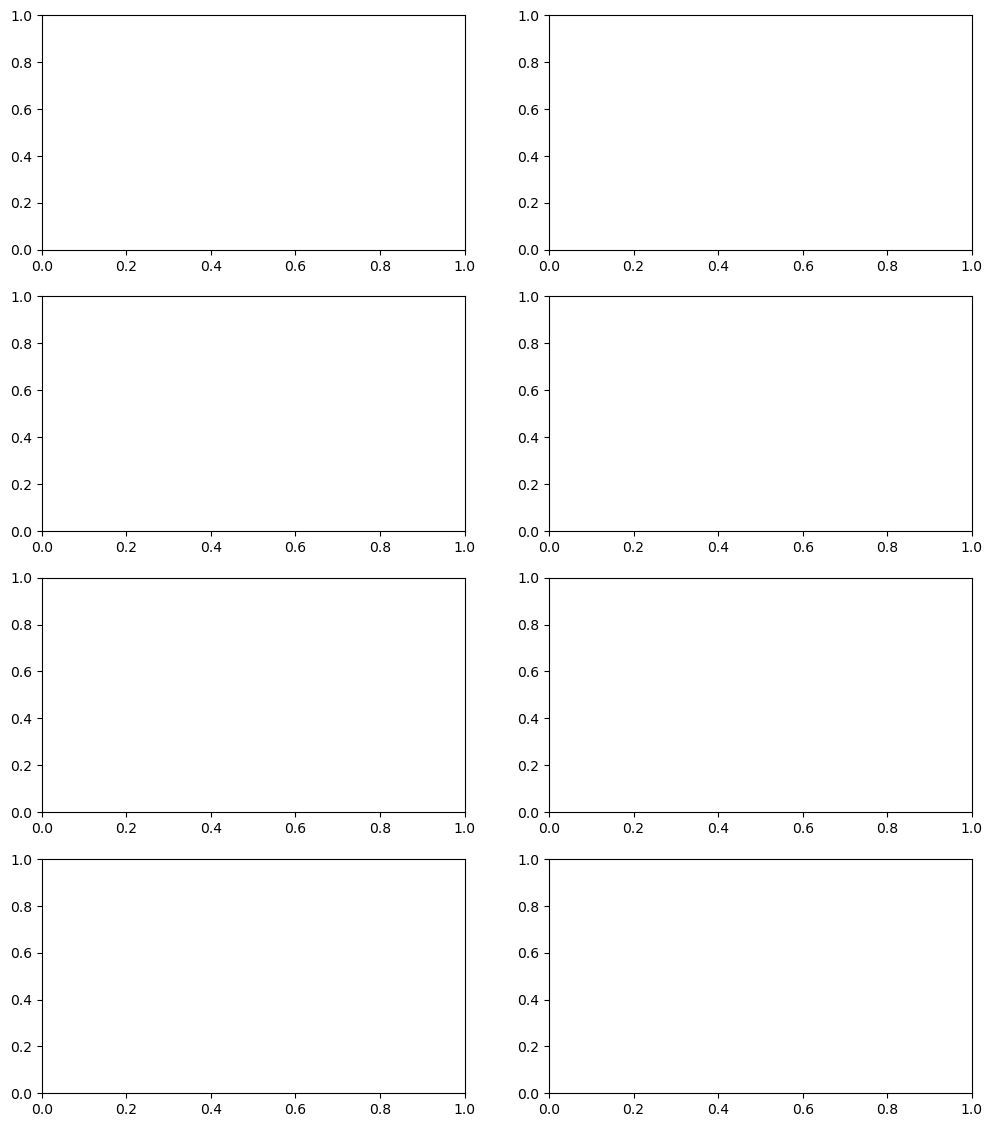

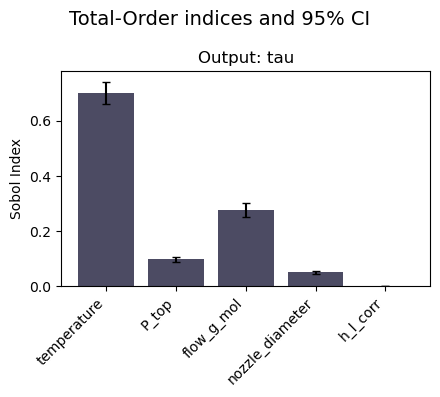

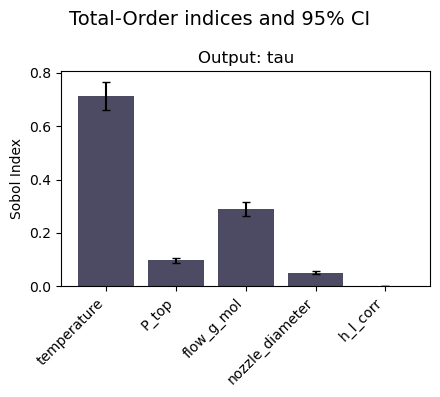

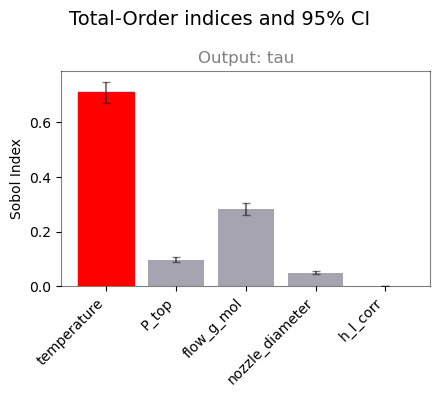

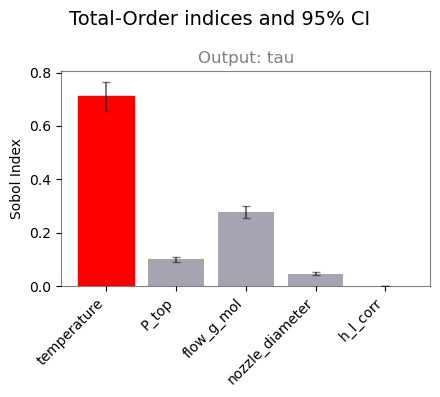

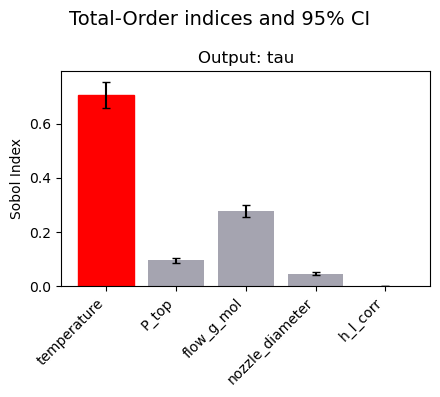

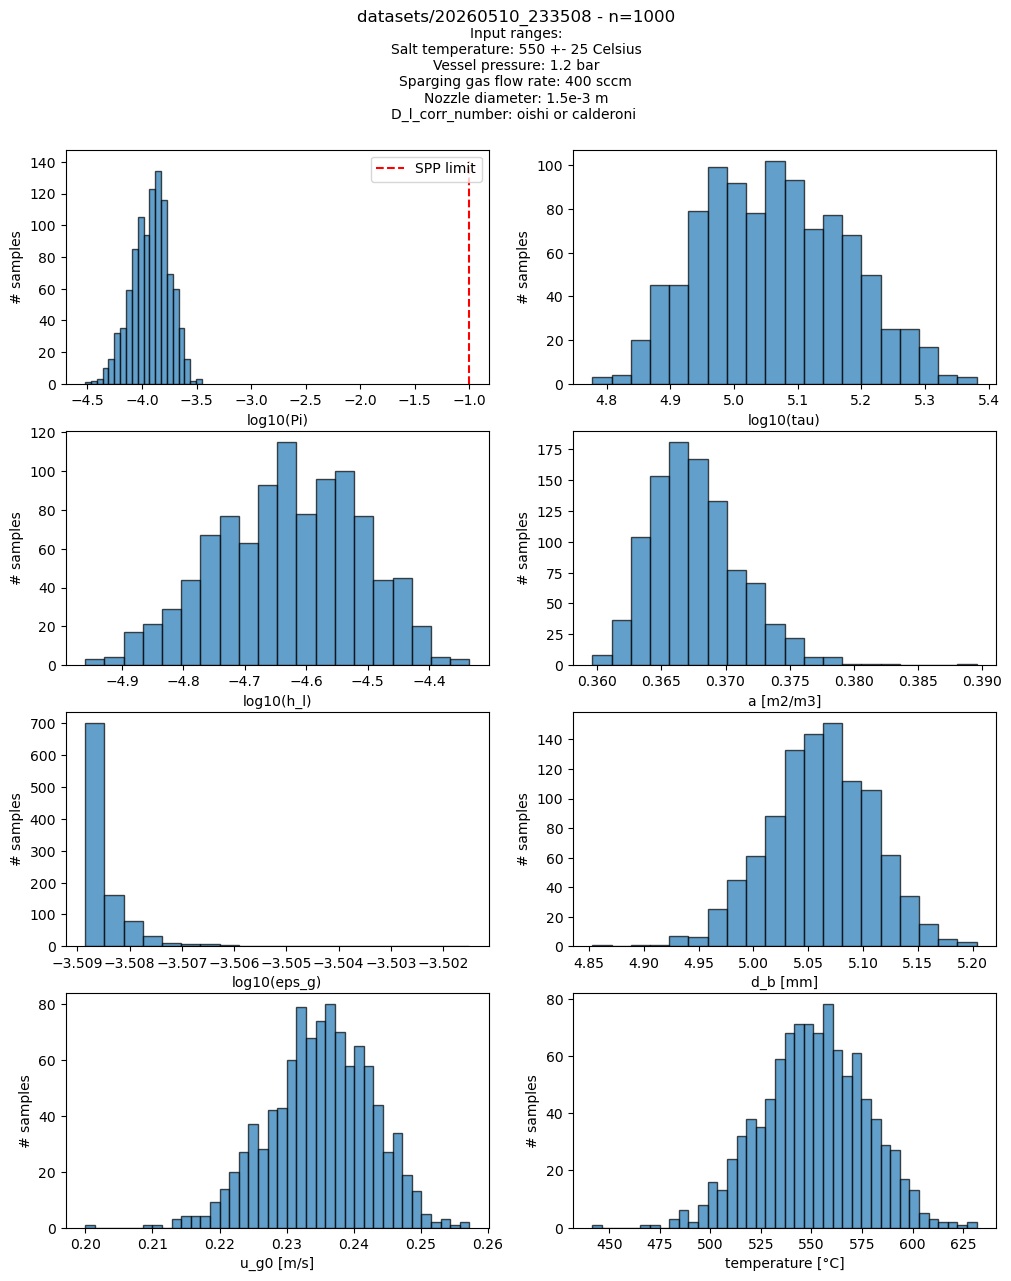

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig,axs = plt.subplots(4,2, figsize=(12,14))
PP_data = pd.read_csv(FOLDER / "PP_data.csv")
plt.sca(axs[0,0])
plt.hist(np.log10(PP_data["Pi"].values), bins=20, edgecolor='black', alpha=0.7)
plt.vlines(np.log10(0.1), ymin=0, ymax=plt.gca().get_ylim()[1], colors="red", linestyles="dashed", label="SPP limit")
plt.xlabel("log10(Pi)")
plt.ylabel("# samples")
plt.legend()

axs[0,1].hist(np.log10(PP_data["tau"].values), bins=20, edgecolor='black', alpha=0.7)
axs[0,1].set_xlabel("log10(tau)")
axs[0,1].set_ylabel("# samples")

axs[1,0].hist(np.log10(PP_data["h_l"].values), bins=20, edgecolor='black', alpha=0.7)
axs[1,0].set_xlabel("log10(h_l)")
axs[1,0].set_ylabel("# samples")

axs[1,1].hist((PP_data["a"].values), bins=20, edgecolor='black', alpha=0.7)
axs[1,1].set_xlabel("a [m2/m3]")
axs[1,1].set_ylabel("# samples")

# axs[2,0].hist((PP_data["eps_g"].values), bins=20, edgecolor='black', alpha=0.7)
# axs[2,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*1e2:.3f}"))
# axs[2,0].set_xlabel("eps_g [%]")
""" added"""
axs[2,0].hist(np.log10(PP_data["eps_g"].values), bins=20, edgecolor='black', alpha=0.7)
axs[2,0].set_xlabel("log10(eps_g)")
axs[2,0].set_ylabel("# samples")

axs[2,1].hist((PP_data["d_b"].values), bins=20, edgecolor='black', alpha=0.7)
axs[2,1].set_xlabel("d_b [mm]")
axs[2,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*1e3:.2f}"))
axs[2,1].set_ylabel("# samples")

axs[3,0].hist((PP_data["u_g0"].values), bins=40, edgecolor='black', alpha=0.7)
axs[3,0].set_xlabel("u_g0 [m/s]")
axs[3,0].set_ylabel("# samples")

axs[3,1].hist((X["temperature"].values), bins=40, edgecolor='black', alpha=0.7)
axs[3,1].set_xlabel("temperature [°C]")
axs[3,1].set_ylabel("# samples")

# str_ranges = "Input ranges:\n" + "\n".join([f"{names_dict.get(param, param)}: [{problem['bounds'][i][0]}, {problem['bounds'][i][1]}] {units_dict.get(param, '')}" for i, param in enumerate(problem["names"])])
str_ranges = "Input ranges:\n" + "\n".join([f"{names_dict.get(param, param)}: {problem['bounds'][i]} {units_dict.get(param, '')}" for i, param in enumerate(problem["names"])])

fig.text(0.5,0.9,str_ranges, fontsize=10, ha='center', va='bottom',)
# fig.text(0.5,0.88,"Artificially increased breeder density (5000 kg/m³)", fontsize=20, ha='center', va='bottom',)

plt.suptitle(f"{FOLDER} - n={len(PP_data)}")
plt.savefig(FOLDER / "postprocessing" / "distributions.png")
plt.show()

95% confidence interval for tau: [0.80  2.23 ] day


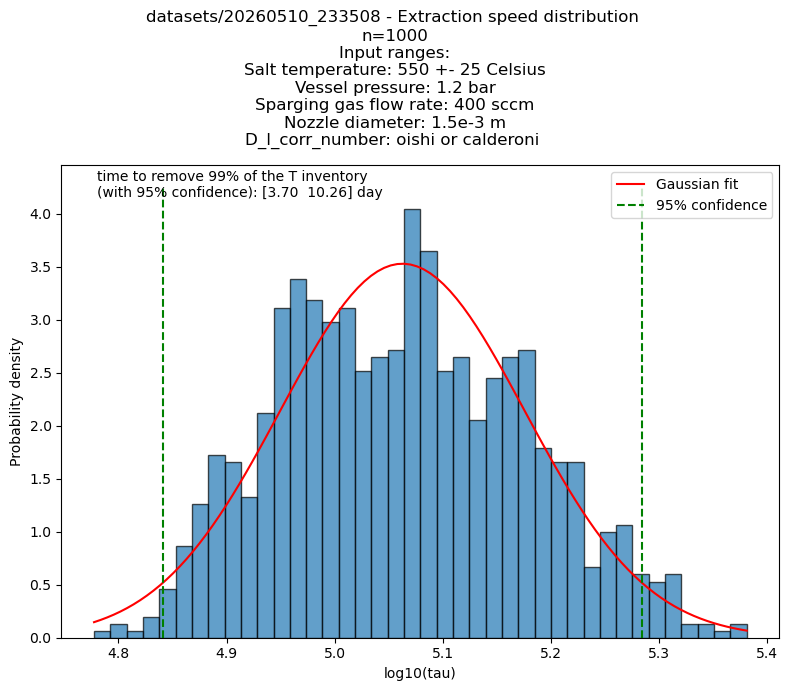

In [29]:
from scipy.stats import norm

log_tau = np.log10(PP_data["tau"].values)
plt.figure(figsize=(8,7))
plt.hist(log_tau, bins=40, edgecolor='black', alpha=0.7, density=True)
plt.xlabel("log10(tau)")
plt.ylabel("Probability density")

# tau_mean = np.mean(log_tau)
# tau_std = np.std(log_tau)
log_tau_mean, log_tau_std = norm.fit(log_tau)
x = np.linspace(log_tau.min(), log_tau.max(), 100)

pdf = norm.pdf(x, log_tau_mean, log_tau_std)

# # equivalent 
# gaussian = (1/(log_tau_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - log_tau_mean) / log_tau_std) ** 2)
# np.allclose(pdf, gaussian)


plt.plot(x, pdf, color='red', label='Gaussian fit')

log_tau_95 = [log_tau_mean - 1.96*log_tau_std, log_tau_mean + 1.96*log_tau_std]

plt.vlines(log_tau_95, ymin=0, ymax=plt.gca().get_ylim()[1], colors="green", linestyles="dashed", label="95% confidence")
plt.legend()

tau_95 = np.power(10,log_tau_95) * ureg.s
annotation = f"time to remove 99% of the T inventory \n(with 95% confidence): {np.log(100) * tau_95.to('days'):<5.2f}"
plt.annotate(annotation, xy=(0.05, 0.99), xycoords='axes fraction', fontsize=10, verticalalignment='top')

plt.suptitle(f"{FOLDER} - Extraction speed distribution \nn={len(PP_data)}\n{str_ranges}")
plt.tight_layout()
plt.savefig(FOLDER / "postprocessing" / "tau_distribution_fitted.png")
print(f"95% confidence interval for tau: {tau_95.to('days'):<5.2f}")
plt.show()

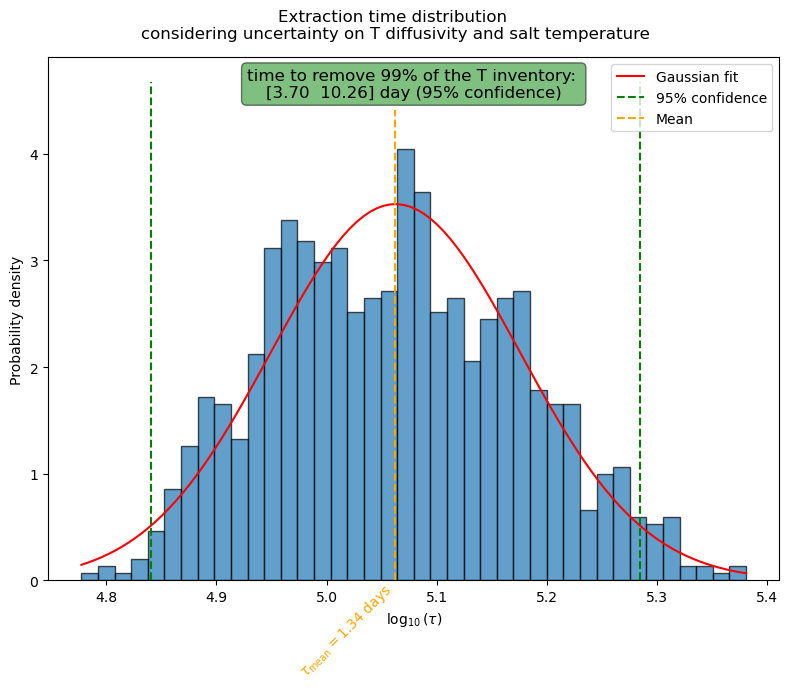

In [30]:
if CLEAN:
    from scipy.stats import norm

    log_tau = np.log10(PP_data["tau"].values)
    plt.figure(figsize=(8,7))
    plt.hist(log_tau, bins=40, edgecolor='black', alpha=0.7, density=True)
    plt.xlabel(r"$\log_{10}(\tau)$")
    plt.ylabel("Probability density")

    # tau_mean = np.mean(log_tau)
    # tau_std = np.std(log_tau)
    log_tau_mean, log_tau_std = norm.fit(log_tau)
    x = np.linspace(log_tau.min(), log_tau.max(), 100)

    pdf = norm.pdf(x, log_tau_mean, log_tau_std)

    # # equivalent 
    # gaussian = (1/(log_tau_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - log_tau_mean) / log_tau_std) ** 2)
    # np.allclose(pdf, gaussian)


    plt.plot(x, pdf, color='red', label='Gaussian fit')

    log_tau_95 = [log_tau_mean - 1.96*log_tau_std, log_tau_mean + 1.96*log_tau_std]

    plt.vlines(log_tau_95, ymin=0, ymax=plt.gca().get_ylim()[1]*1.1, colors="green", linestyles="dashed", label="95% confidence")
    plt.vlines(log_tau_mean, ymin=0, ymax=plt.gca().get_ylim()[1]*0.9, colors="orange", linestyles="dashed", label="Mean")
    plt.text(log_tau_mean, 0, rf"$\tau_{{\text{{mean}}}} = {10**log_tau_mean/(24*3600):.2f} $ days", verticalalignment='top', horizontalalignment='right', rotation=45, color="orange")
    plt.legend()

    tau_95 = np.power(10,log_tau_95) * ureg.s
    annotation = f"time to remove 99% of the T inventory: \n{np.log(100) * tau_95.to('days'):<5.2f} (95% confidence)"
    plt.annotate(annotation, xy=(0.5, 0.98), xycoords='axes fraction', fontsize=12, verticalalignment='top', horizontalalignment='center', bbox=dict(boxstyle="round", facecolor="g", alpha=0.5))
    plt.suptitle("Extraction time distribution \nconsidering uncertainty on T diffusivity and salt temperature")
    plt.tight_layout()
    plt.savefig(FOLDER / "postprocessing" / "tau_distribution_fitted_clean.png")
    plt.show()

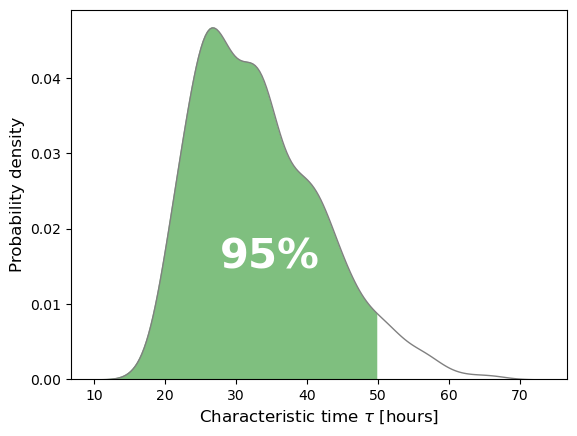

In [67]:
import seaborn as sns
percentile = 95
threshold = np.percentile(PP_data["tau"].values,percentile)

for clip in [(1e4/3600, threshold/3600), None]:
    if clip is None:
        color = 'none'
        edgecolor = 'grey'
    else:
        color = 'green'
        edgecolor = 'none'
    sns.kdeplot(PP_data["tau"].values/3600, fill=True, clip=clip, color=color, edgecolor=edgecolor, alpha=0.5)
    # plt.hist(PP_data["tau"].values/3600, range=((PP_data["tau"].values/3600).min(), threshold/3600), bins=20, fill=True, edgecolor='black', alpha=0.7, density=True, histtype="stepfilled", color="C0")
    # plt.hist(PP_data["tau"].values/3600, bins=20, fill=True, edgecolor='black', alpha=0.7, density=True, histtype="step", color="C0")

# color area where log_tau > threshold

# annotate the plot with the threshold
# plt.annotate(f'95% prob.: {threshold:.2f}', xy=(10**threshold, 0.3e-5),  fontsize=10)

plt.annotate(f'{percentile}%', xycoords='axes fraction', xy=(0.3, 0.3),  fontsize=30, color='white', weight='bold')

plt.xlabel(r'Characteristic time $\tau$ [hours]', fontsize=12)
plt.ylabel("Probability density", fontsize=12)

threshold_in_days = threshold / (3600*24)
# plt.title(f"There's a {percentile}% probability \nthat the characteristic time is less than {threshold_in_days:.2f} days", fontsize=12, loc='left', weight='bold')
plt.savefig(FOLDER / "postprocessing" / "tau_distribution_kde.svg")
plt.show()

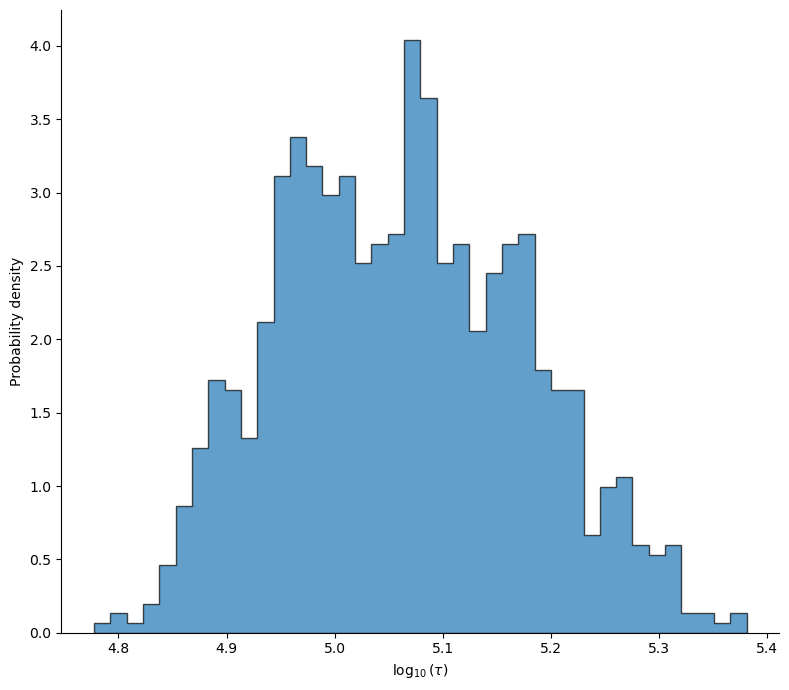

In [ ]:
if CLEAN:
    from scipy.stats import norm

    log_tau = np.log10(PP_data["tau"].values)
    plt.figure(figsize=(8,7))
    plt.hist(log_tau, bins=40, edgecolor='black', alpha=0.7, density=True, histtype="stepfilled")



    plt.xlabel(r"$\log_{10}(\tau)$")
    plt.ylabel("Probability density")

    # # equivalent 
    # gaussian = (1/(log_tau_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - log_tau_mean) / log_tau_std) ** 2)
    # np.allclose(pdf, gaussian)


    log_tau_95 = [log_tau_mean - 1.96*log_tau_std, log_tau_mean + 1.96*log_tau_std]

    # plt.vlines(log_tau_95, ymin=0, ymax=plt.gca().get_ylim()[1]*1.1, colors="green", linestyles="dashed", label="95% confidence")
    # plt.vlines(log_tau_mean, ymin=0, ymax=plt.gca().get_ylim()[1]*0.9, colors="orange", linestyles="dashed", label="Mean")
    # plt.text(log_tau_mean, 0, rf"$\tau_{{\text{{mean}}}} = {10**log_tau_mean/(24*3600):.2f} $ days", verticalalignment='top', horizontalalignment='right', rotation=45, color="orange")
    # plt.legend()

    tau_95 = np.power(10,log_tau_95) * ureg.s
    annotation = f"time to remove 99% of the T inventory: \n{np.log(100) * tau_95.to('days'):<5.2f} (95% confidence)"
    # plt.annotate(annotation, xy=(0.5, 0.98), xycoords='axes fraction', fontsize=12, verticalalignment='top', horizontalalignment='center', bbox=dict(boxstyle="round", facecolor="g", alpha=0.5))
    
    # remove spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(FOLDER / "postprocessing" / "tau_distribution_fitted_clean.png")
    plt.show()

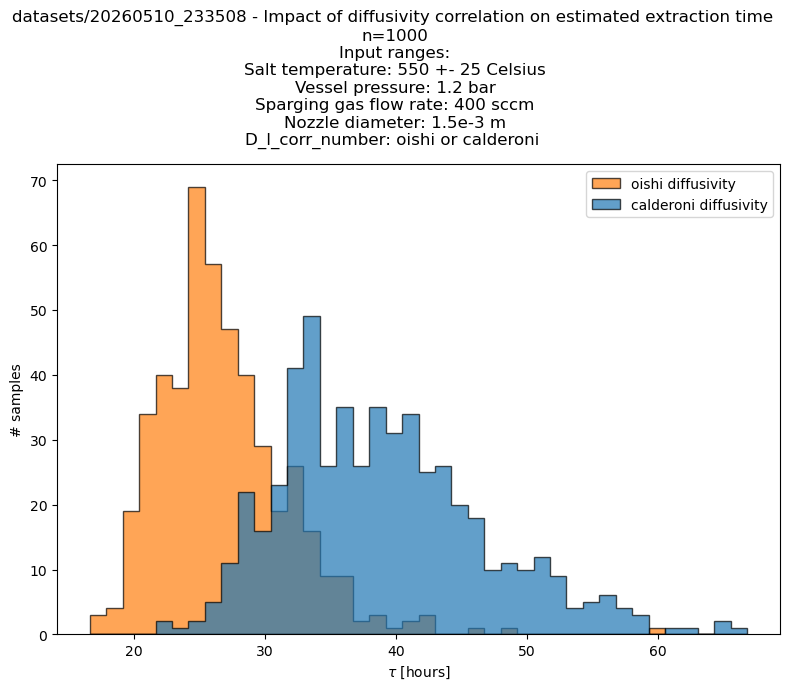

In [32]:
# """ what is the impact of chosen correlation on performance prediction """
log_tau_calderoni = [log_tau[i] for i in range(len(log_tau)) if PP_data["D_l_corr"].values[i] == "D_l"]
log_tau_oishi = [log_tau[i] for i in range(len(log_tau)) if PP_data["D_l_corr"].values[i] == "D_l_oishi"]
# log_tau_briggs = [log_tau[i] for i in range(len(log_tau)) if PP_data["h_l_corr"].values[i] == "h_l_briggs"]
log_tau_concat = log_tau_calderoni + log_tau_oishi # + log_tau_briggs

log_tau_bounds = [np.min(log_tau_concat), np.max(log_tau_concat)]
tau_bounds = np.power(10,log_tau_bounds) * ureg.s

plt.figure(figsize=(8,7))
plt.hist([np.power(10, log_tau_calderoni)/3600, np.power(10, log_tau_oishi)/3600], bins=40, edgecolor='black', alpha=0.7,
          density=False, label=["calderoni diffusivity","oishi diffusivity"], stacked=False, histtype='stepfilled')

# plt.hist([log_tau_calderoni, log_tau_oishi], bins=40, edgecolor='black', alpha=0.7,
#           density=False, label=["calderoni diffusivity","oishi diffusivity"], stacked=False, histtype='stepfilled')
# plt.vlines(log_tau_bounds, ymin=0, ymax=plt.gca().get_ylim()[1], colors="green", linestyles="dashed", label="bounds")
# annotation = f"time to remove 99% of the T inventory: {np.log(100) * tau_bounds.to('days'):<5.2f}"
# plt.annotate(annotation, xy=(0.05, 0.99), xycoords='axes fraction', fontsize=10, verticalalignment='top')
# plt.xscale('log')
plt.xlabel(r"$\tau$ [hours]")
plt.ylabel("# samples")

plt.legend()
plt.suptitle(f"{FOLDER} - Impact of diffusivity correlation on estimated extraction time \nn={len(PP_data)}\n{str_ranges}")
plt.tight_layout()
plt.savefig(FOLDER / "postprocessing" / "tau_distribution_correlation.png")
plt.show()

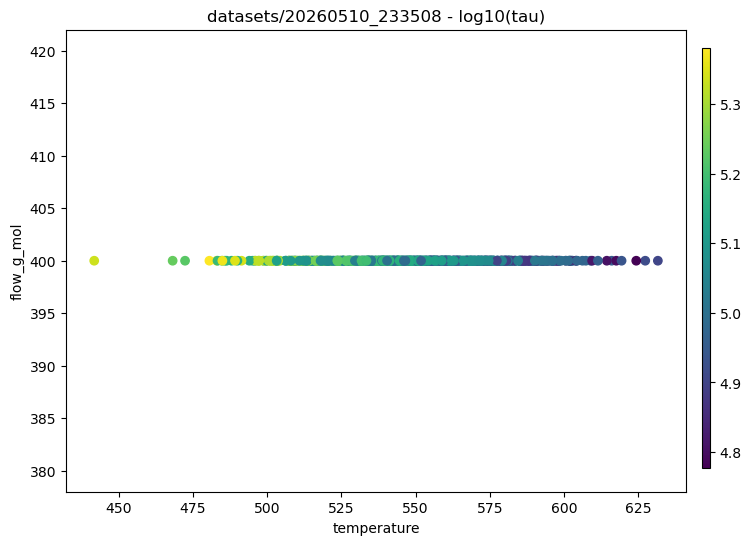

In [ ]:
"""" visualize effect of the two higher sobol entries """
x_name = "temperature"
y_name = "flow_g_mol"
c_name = "tau"
Y_plot = np.log10(Y[c_name])

fig,axs = plt.subplots(1,1, figsize=(8,6))
plt.sca(axs)
plt.scatter(X[x_name], X[y_name], c=Y_plot, cmap="viridis", vmin=Y_plot.min(), vmax=Y_plot.max())

plt.title(f"{FOLDER} - log10({c_name})")

plt.xlabel(x_name)
plt.ylabel(y_name)
plt.colorbar(cax=fig.add_axes([0.92, 0.15, 0.01, 0.7]))

plt.savefig(FOLDER / "postprocessing" / "scatter.png")
plt.show()

/tmp/ipykernel_160204/1391669839.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = fit(polyn,df[x_names[i]].values, df[y_name].values, p0=p0)


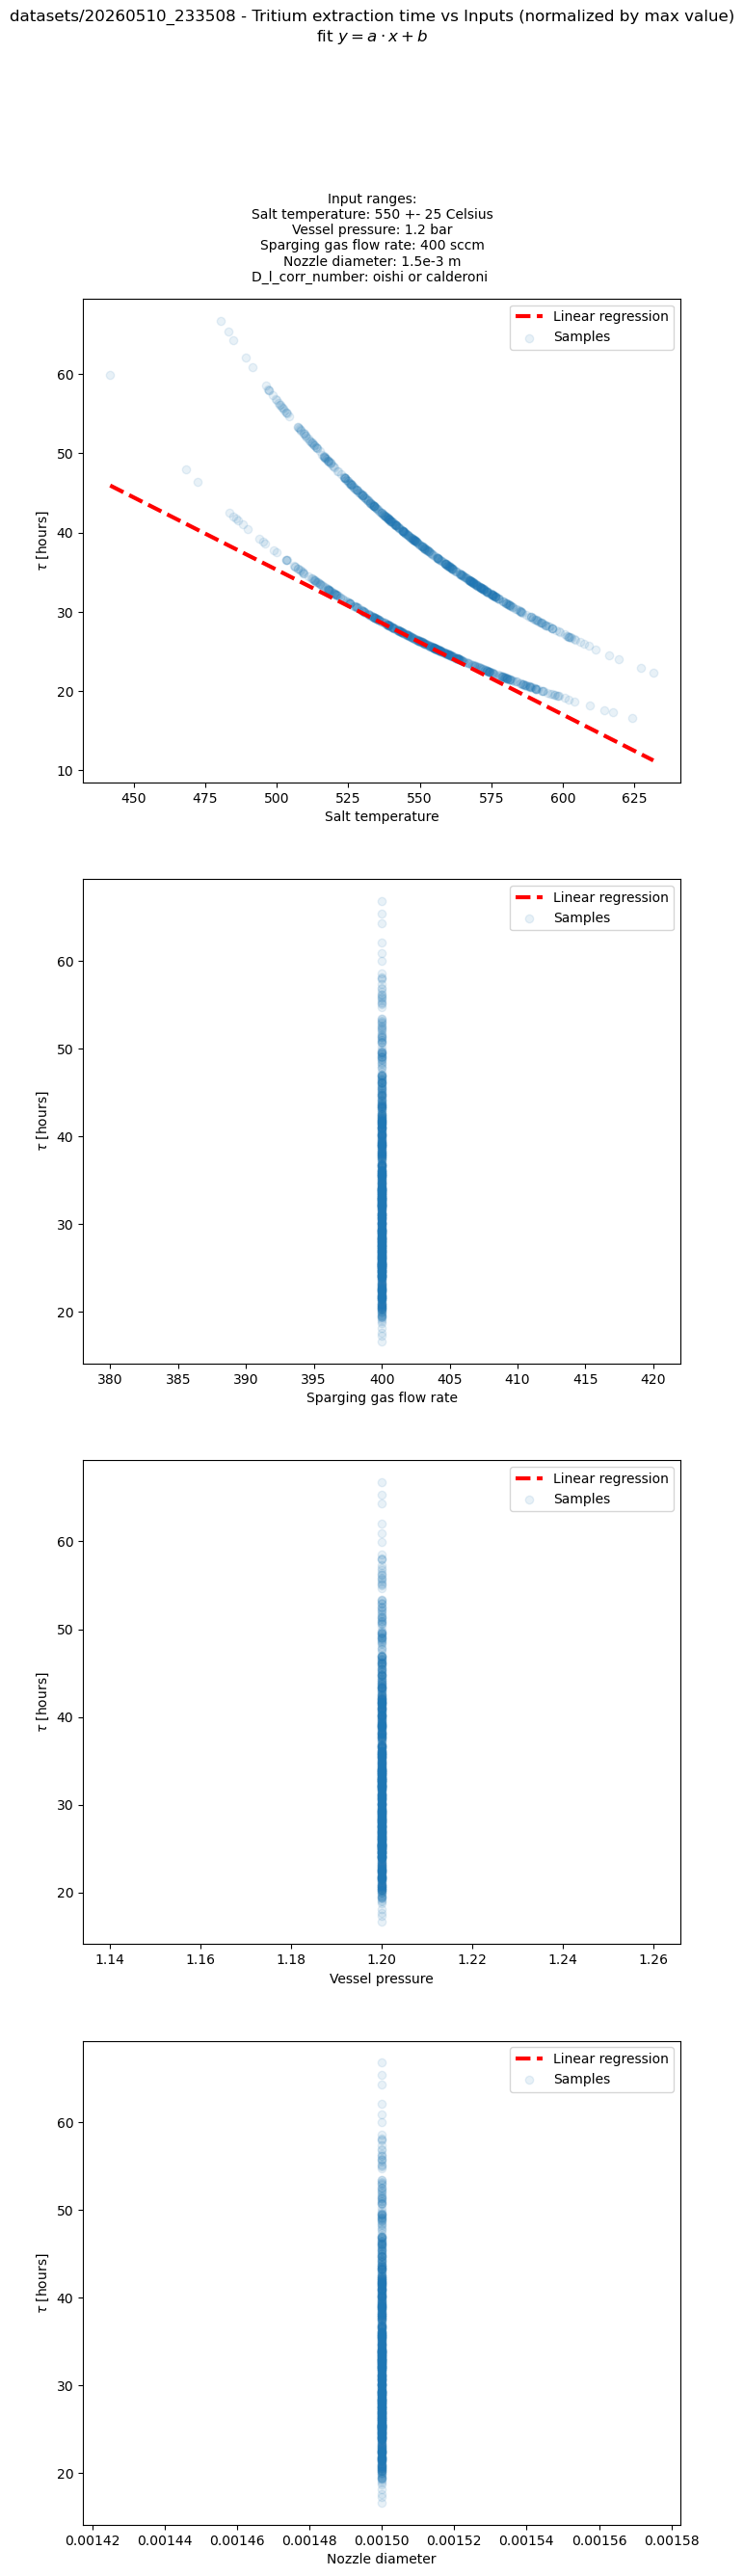

In [ ]:
""" impact of individual parameters"""
from scipy.optimize import curve_fit as fit

shape = (4,1)
y_name = "tau"
x_names=["temperature", "flow_g_mol", "P_top", "nozzle_diameter"]
n = len(x_names) - 1
# remove column if "D_l_corr" in PP_data.columns:
# X = X.drop(columns=["D_l_corr"])
df = pd.DataFrame(pd.concat([PP_data, X], axis=1), columns=np.append(x_names, y_name))

df_norm = pd.DataFrame()
for column in df.columns:
    df_norm[column] = df[column] / df[column].max()

def polyn(x, d, a, b):
    return a * (x)**1 + b

fig, axes = plt.subplots(*shape, figsize = (8, 30))
for i in range(len(x_names)):
    # test = np.array(range(len(x_names))).reshape(shape)[0]
    # idxs = tuple(np.argwhere(np.array(range(len(x_names))).reshape(shape) == i)[0])       
    axes[i].set_ylabel(r"$\tau$ [hours]")
    axes[i].set_xlabel(names_dict.get(x_names[i], x_names[i]))
    try:
        p0 = [1, 1, 1]
        popt, _ = fit(polyn,df[x_names[i]].values, df[y_name].values, p0=p0)
    except RuntimeError:
        p0 = [-20, 1, 1]
        popt, _ = fit(polyn,df[x_names[i]].values, df[y_name].values,p0=p0, maxfev=50000)
    d, a, b = popt
    x_plot = np.linspace(df[x_names[i]].min(), df[x_names[i]].max(), 100)
    y_plot = polyn(x_plot, *popt)
    axes[i].plot(x_plot, y_plot/4600, linestyle='--', linewidth=3, color='red', label="Linear regression") # f"{a:.1e} * x^{d:.1e} + {b:.1e}
    axes[i].scatter(df[x_names[i]], df[y_name]/3600, alpha=0.1, label="Samples")
    axes[i].legend()
    axes[i].grid(False)

        
        
# axes[0, 0].set_yticks(axes[0, 1].get_yticks())
# axes[0, 0].set_ylim(axes[0, 1].get_ylim())
# axes[n, n].set_xticks(axes[n-1, n].get_yticks())
# axes[n, n].set_xlim(axes[n-1, n].get_ylim())

fig.text(0.5,0.885,str_ranges, fontsize=10, ha='center', va='bottom',)
plt.suptitle(f"{FOLDER} - Tritium extraction time vs Inputs (normalized by max value)\nfit {r"$y = a \cdot x + b$"}")

# plt.tight_layout()
plt.savefig(FOLDER / "postprocessing" / "tau_vs_inputs.png")

In [ ]:
""" impact of individual parameters"""
from scipy.optimize import curve_fit as fit

shape = (4,1)
y_name = "tau"
x_names=["temperature", "flow_g_mol", "P_top", "nozzle_diameter"]
n = len(x_names) - 1
# remove column if "D_l_corr" in PP_data.columns:
X = X.drop(columns=["D_l_corr"])
df = pd.DataFrame(pd.concat([PP_data, X], axis=1), columns=np.append(x_names, y_name))

df_norm = pd.DataFrame()
for column in df.columns:
    df_norm[column] = df[column] / df[column].max()

def polyn(x, d, a, b):
    return a * (x)**1 + b

fig, axes = plt.subplots(*shape, figsize = (20, 13))
plt.sca(axes[0,0])
for i in range(len(x_names)):
    test = np.array(range(len(x_names))).reshape(shape)[0]
    idxs = tuple(np.argwhere(np.array(range(len(x_names))).reshape(shape) == i)[0])       
    axes[idxs].set_ylabel(names_dict.get(y_name, y_name))
    axes[idxs].set_xlabel(names_dict.get(x_names[i], x_names[i]))
    try:
        p0 = [1, 1, 1]
        popt, _ = fit(polyn,df_norm[x_names[i]].values, df_norm[y_name].values, p0=p0)
    except RuntimeError:
        p0 = [-20, 1, 1]
        popt, _ = fit(polyn,df_norm[x_names[i]].values, df_norm[y_name].values,p0=p0, maxfev=50000)
    d, a, b = popt
    x_plot = np.linspace(df_norm[x_names[i]].min(), df_norm[x_names[i]].max(), 100)
    y_plot = polyn(x_plot, *popt)
    axes[idxs].plot(x_plot, y_plot, linestyle='--', color='red', label=f"a = {a:.3f}") # f"{a:.1e} * x^{d:.1e} + {b:.1e}
    axes[idxs].legend()
    axes[idxs].scatter(x_names[i], y_name, alpha=0.5, data=df_norm)
    axes[idxs].grid(True)

        
        
# axes[0, 0].set_yticks(axes[0, 1].get_yticks())
# axes[0, 0].set_ylim(axes[0, 1].get_ylim())
# axes[n, n].set_xticks(axes[n-1, n].get_yticks())
# axes[n, n].set_xlim(axes[n-1, n].get_ylim())

fig.text(0.5,0.885,str_ranges, fontsize=10, ha='center', va='bottom',)
plt.suptitle(f"{FOLDER} - Tritium extraction time vs Inputs (normalized by max value)\nfit {r"$y = a \cdot x + b$"}")

# plt.tight_layout()
plt.savefig(FOLDER / "postprocessing" / "tau_vs_inputs.png")

KeyError: "['D_l_corr'] not found in axis"

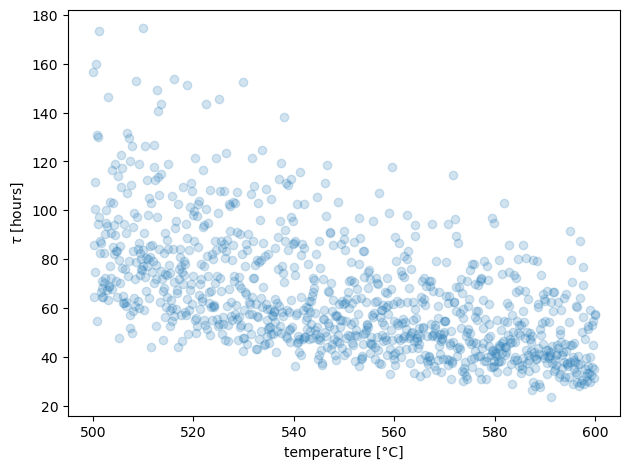

In [ ]:
""" plot tau vs temperature """
df = pd.DataFrame(pd.concat([PP_data, X], axis=1), columns=np.append(x_names, y_name))


plt.scatter(df["temperature"], df["tau"]/3600, alpha=0.2)
plt.ylabel(r"$\tau$ [hours]")
plt.xlabel("temperature [°C]")
plt.tight_layout()
plt.savefig("figures/tau_vs_temperature.png")

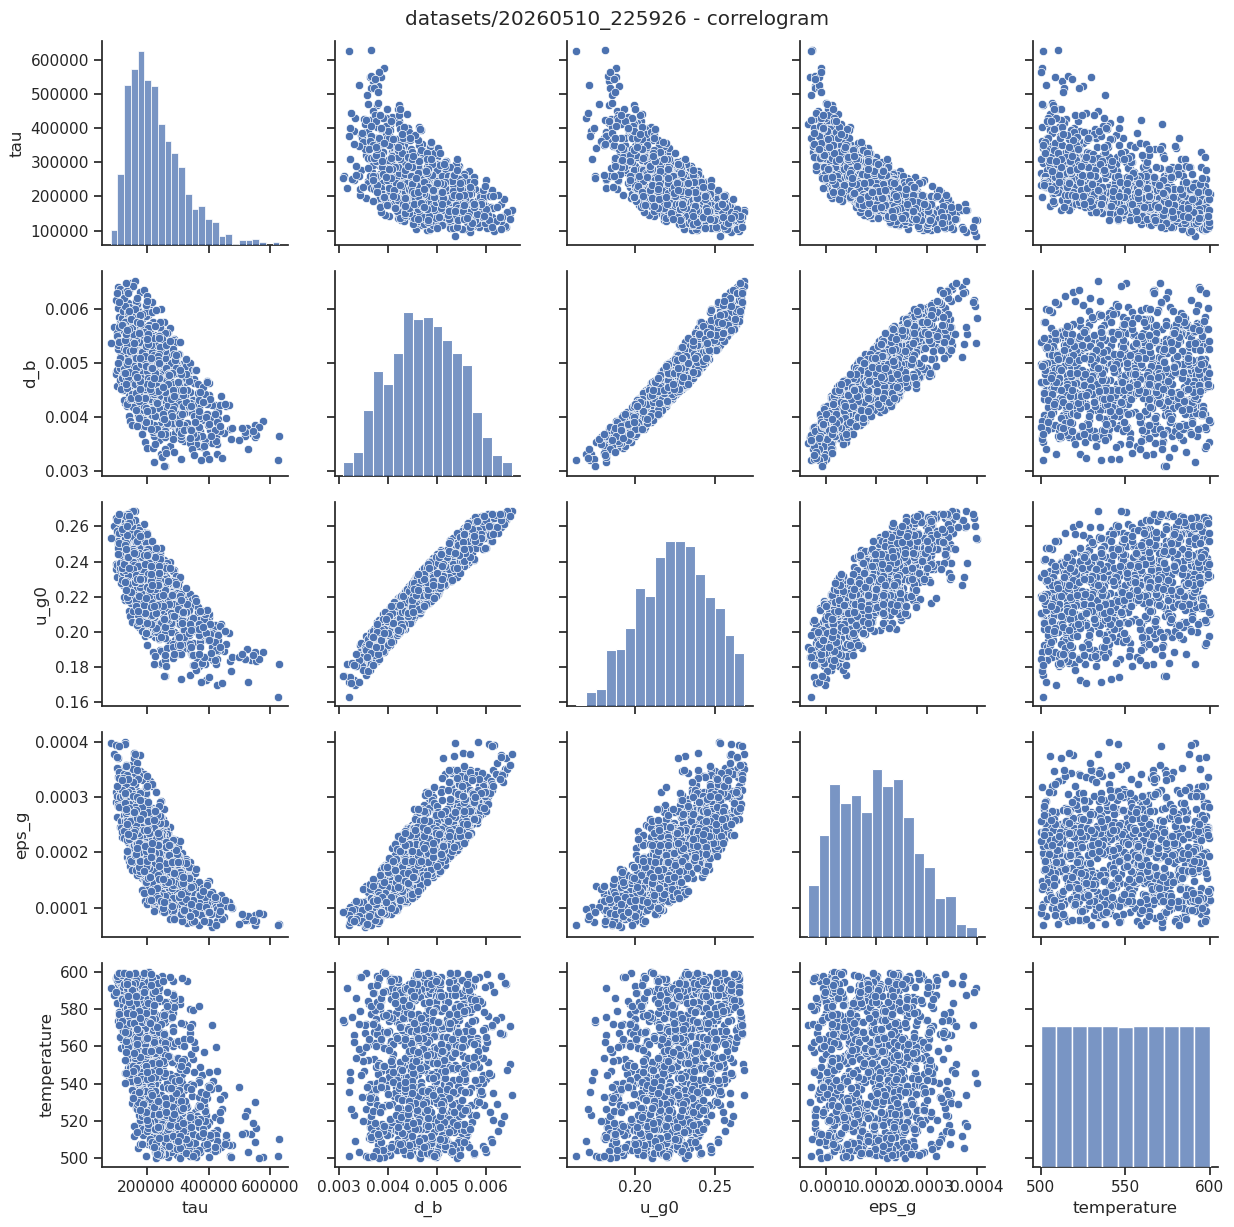

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.DataFrame(pd.concat([PP_data, X], axis=1), columns=["tau", "d_b", "u_g0", "eps_g","temperature"])

# normalize dataframe values
# for column in df.columns:
#     df[column] = df[column] / df[column].max() 
    

# with regression
sns.set_theme(context="notebook", style="ticks")
p = sns.pairplot(df, kind="scatter") # plot_kws=dict(scatter_kws=dict(alpha=0.01))

plt.suptitle(f"{FOLDER} - correlogram")
plt.tight_layout()
plt.savefig(FOLDER / "postprocessing" / "correlogram.png")
plt.show()



/tmp/ipykernel_146101/981884659.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = fit(polyn,df_norm[columns[j]].values, df_norm[columns[i]].values, p0=p0)
/tmp/ipykernel_146101/981884659.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = fit(polyn,df_norm[columns[j]].values, df_norm[columns[i]].values, p0=p0)
/tmp/ipykernel_146101/981884659.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = fit(polyn,df_norm[columns[j]].values, df_norm[columns[i]].values, p0=p0)
/tmp/ipykernel_146101/981884659.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = fit(polyn,df_norm[columns[j]].values, df_norm[columns[i]].values, p0=p0)
/tmp/ipykernel_146101/981884659.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = fit(polyn,df_norm[columns[j]].values, df_norm[columns[i]].values, p0=p0)
/tmp/ipykernel_146101/981884659.py:

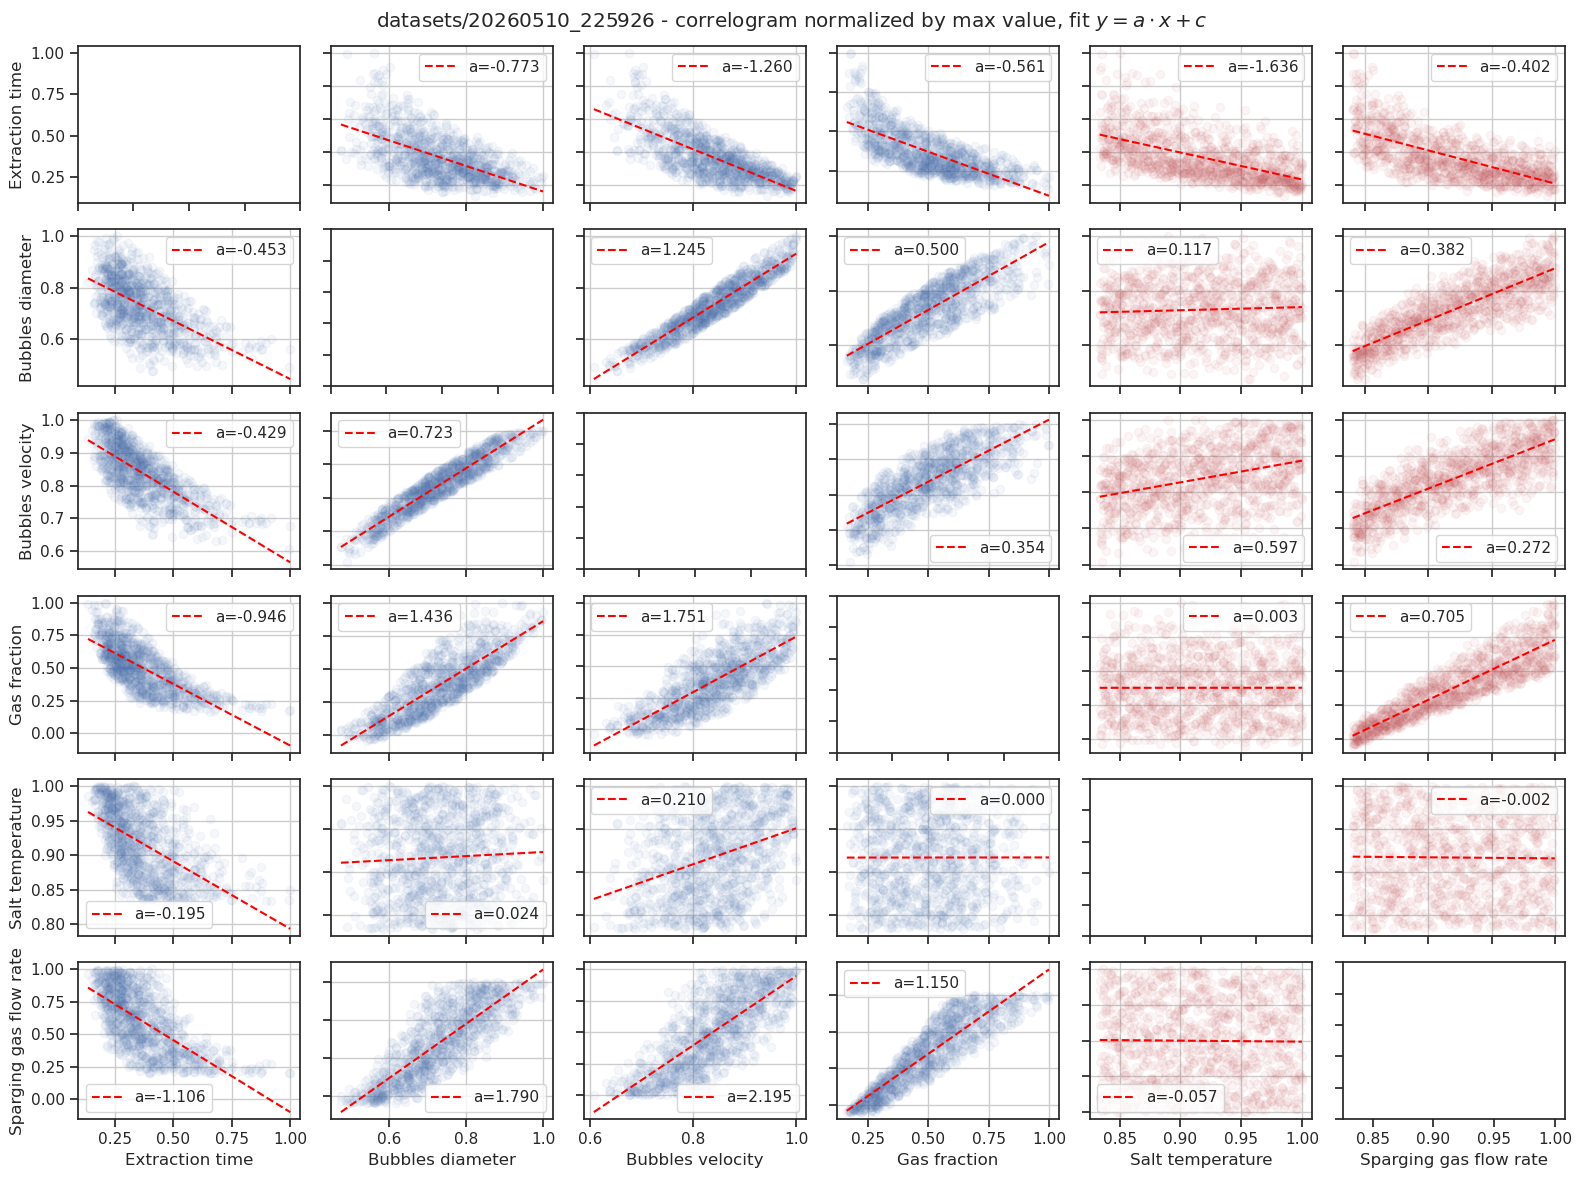

In [ ]:
from scipy.optimize import curve_fit as fit

columns=["tau", "d_b", "u_g0", "eps_g","temperature","flow_g_mol"]
n = len(columns) - 1
df = pd.DataFrame(pd.concat([PP_data, X], axis=1), columns=columns)
df_norm = pd.DataFrame()
for column in df.columns:
    df_norm[column] = df[column] / df[column].max()

def polyn(x, d, a, c):
    return a * (x)**1 + c

fig, axes = plt.subplots(len(columns), len(columns), figsize = (16, 12), tight_layout=False)

for i in range(len(columns)):
    for j in range(len(columns)):
                
        if j == 0:
            axes[i, j].set_ylabel(names_dict.get(columns[i], columns[i]))
        else:
            axes[i, j].set_yticklabels([])
            
        if i == len(columns)-1:
            axes[i, j].set_xlabel(names_dict.get(columns[j], columns[j]))
        else:
            axes[i, j].set_xticklabels([])
        # If this is the main diagonal, add histograms
        if i == j:
            pass
            # axes[i, j].hist(columns[j], bins=15, alpha=0.5, data=df_norm)
            # axes[i,j].grid(False)
        # If this is the upper/lower triangle, add scatter plots with regression
        else:
            try:
                p0 = [1, 1, 1]
                popt, _ = fit(polyn,df_norm[columns[j]].values, df_norm[columns[i]].values, p0=p0)
            except RuntimeError:
                p0 = [-20, 1, 1]
                popt, _ = fit(polyn,df_norm[columns[j]].values, df_norm[columns[i]].values,p0=p0, maxfev=50000)
            d, a, b = popt
            x_plot = np.linspace(df_norm[columns[j]].min(), df_norm[columns[j]].max(), 100)
            y_plot = polyn(x_plot, *popt)
            color = "r" if j >= len(columns)-2 else "b"
            axes[i, j].plot(x_plot, y_plot, linestyle='--', color='red', label=f"a={a:.3f}") # f"{a:.1e} * x^{d:.1e} + {c:.1e}
            axes[i, j].legend()
            axes[i, j].scatter(columns[j], columns[i], alpha=0.05, data=df_norm, color=color)
            axes[i,j].grid(True)

        
        
axes[0, 0].set_yticks(axes[0, 1].get_yticks())
axes[0, 0].set_ylim(axes[0, 1].get_ylim())
axes[n, n].set_xticks(axes[n-1, n].get_yticks())
axes[n, n].set_xlim(axes[n-1, n].get_ylim())

plt.suptitle(f"{FOLDER} - correlogram normalized by max value, fit {r"$y = a \cdot x + c$"}")
plt.tight_layout()
plt.savefig(FOLDER / "postprocessing" / "correlogram_norm_fit.png")            